<a href="https://colab.research.google.com/github/kabir-codes/ml-challenge/blob/aarushi/Ml_Challenge_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
import re
from sklearn.model_selection import train_test_split

In [45]:
df = pd.read_csv("/content/sample_data/ml_challenge_dataset.csv")
df

,unique_id,Painting,"On a scale of 1–10, how intense is the emotion conveyed by the artwork?",Describe how this painting makes you feel.,This art piece makes me feel sombre.,This art piece makes me feel content.,This art piece makes me feel calm.,This art piece makes me feel uneasy.,How many prominent colours do you notice in this painting?,How many objects caught your eye in the painting?,How much (in Canadian dollars) would you be willing to pay for this painting?,"If you could purchase this painting, which room would you put that painting in?","If you could view this art in person, who would you want to view it with?",What season does this art piece remind you of?,"If this painting was a food, what would be?",Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.
0,1,The Persistence of Memory,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,The Persistence of Memory,5.0,"The clocks are burnt on a hot desert, it embod...",4 - Agree,3 - Neutral/Unsure,2 - Disagree,1 - Strongly disagree,2.0,4.0,0,Bathroom,By yourself,Fall,Fries,A country song that contrasts nostalgia for th...
2,3,The Persistence of Memory,7.0,This painting makes me feel dread. The clock r...,4 - Agree,1 - Strongly disagree,1 - Strongly disagree,4 - Agree,4.0,3.0,$5,"Bathroom,Dining room","Coworkers/Classmates,By yourself",Fall,Sardines,A melancholy instrumental with a monotone voic...
3,4,The Persistence of Memory,7.0,Deflated,4 - Agree,1 - Strongly disagree,2 - Disagree,4 - Agree,10.0,7.0,a,"Bedroom,Bathroom",Coworkers/Classmates,Winter,a,q
4,5,The Persistence of Memory,7.0,The painting gives me a sense of calmness and ...,3 - Neutral/Unsure,4 - Agree,5 - Strongly agree,3 - Neutral/Unsure,4.0,6.0,300 dollars.,Living room,Friends,"Spring,Summer",Churros.,Radiohead's album in rainbows.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,558,The Water Lily Pond,5.0,Joy and relaxation.,2 - Disagree,4 - Agree,4 - Agree,2 - Disagree,2.0,1.0,$35,"Bedroom,Office,Living room,Dining room","Friends,Family members,Coworkers/Classmates,St...",Spring,green apple,nature forest soundtrack
1682,559,The Water Lily Pond,9.0,This painting makes me feel happy,2 - Disagree,5 - Strongly agree,5 - Strongly agree,1 - Strongly disagree,3.0,3.0,200,"Bedroom,Office,Living room",Friends,"Spring,Summer",Salad,Slow guitar soundtrack
1683,560,The Water Lily Pond,8.0,This painting makes me feel warm and new birth...,1 - Strongly disagree,5 - Strongly agree,3 - Neutral/Unsure,1 - Strongly disagree,2.0,2.0,"200 Dollars, pay for the emotion","Bedroom,Living room","Friends,Family members",Spring,Fresh salad,"Various animal sounds, like bird sounds; and l..."
1684,561,The Water Lily Pond,5.0,makes me feel nonchalant,2 - Disagree,2 - Disagree,4 - Agree,1 - Strongly disagree,4.0,1.0,10,"Bathroom,Office","Friends,Family members,Coworkers/Classmates,St...",Spring,apple,simon and garfunkel


In [46]:
# Renaming Column names

df = df.rename(columns={'unique_id': 'rid',
                        'Painting': 'label', 'On a scale of 1–10, how intense is the emotion conveyed by the artwork?': 'intensity',
                        'Describe how this painting makes you feel.': 'feeling',
                        'This art piece makes me feel sombre.': 'sombre?',
                        'This art piece makes me feel content.': 'content?',
                        'This art piece makes me feel calm.': 'calm?',
                        'This art piece makes me feel uneasy.': 'uneasy?',
                        'How many prominent colours do you notice in this painting?': 'num_colors',
                        'How many objects caught your eye in the painting?': 'num_objects',
                        'How much (in Canadian dollars) would you be willing to pay for this painting?': 'worth',
                        'If you could purchase this painting, which room would you put that painting in?': 'place',
                        'If you could view this art in person, who would you want to view it with?': 'view_with',
                        'What season does this art piece remind you of?': 'season',
                        'If this painting was a food, what would be?': 'food',
                        'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.': 'music'})

In [47]:
# We split the data into training and validation, using the stratified 80/20 split.

# from sklearn.model_selection import train_test_split

# train_df, val_df = train_test_split(
#     df,
#     test_size=0.2,
#     random_state=42,
#     stratify=df["label"]
# )

# We figured that stratified was leaking data so now we try splitting the dataset
# based on the Unique id's

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df["rid"]))

train_df = df.iloc[train_idx].copy()
val_df = df.iloc[val_idx].copy()

In [48]:
# We are writing a function to cross check that both splits don't have any overlap
# Cause if there's overlap then thats data leakage.

def check_group_split_no_overlap(train_df, val_df, group_col="rid", label_col="label"):
    train_groups = set(train_df[group_col])
    val_groups = set(val_df[group_col])

    overlap = train_groups & val_groups

    print(f"Train {group_col} count:", len(train_groups))
    print(f"Validation {group_col} count:", len(val_groups))
    print(f"Overlapping {group_col}s:", len(overlap))

    if len(overlap) == 0:
        print("No group leakage: train and validation have disjoint IDs.")
    else:
        print("Leakage detected! Overlapping IDs found:")
        print(sorted(list(overlap))[:20])

    print("\nTrain label counts:")
    print(train_df[label_col].value_counts())

    print("\nValidation label counts:")
    print(val_df[label_col].value_counts())

    print("\nTrain label proportions:")
    print(train_df[label_col].value_counts(normalize=True))

    print("\nValidation label proportions:")
    print(val_df[label_col].value_counts(normalize=True))


In [49]:
check_group_split_no_overlap(train_df, val_df)


Train rid count: 449
Validation rid count: 113
Overlapping rids: 0
No group leakage: train and validation have disjoint IDs.

Train label counts:
label
The Persistence of Memory    449
The Starry Night             449
The Water Lily Pond          449
Name: count, dtype: int64

Validation label counts:
label
The Persistence of Memory    113
The Starry Night             113
The Water Lily Pond          113
Name: count, dtype: int64

Train label proportions:
label
The Persistence of Memory    0.333333
The Starry Night             0.333333
The Water Lily Pond          0.333333
Name: proportion, dtype: float64

Validation label proportions:
label
The Persistence of Memory    0.333333
The Starry Night             0.333333
The Water Lily Pond          0.333333
Name: proportion, dtype: float64


In [50]:
# Adding column class
# Overwritten by Haseeb
class_map = {
    "The Persistence of Memory": 0,
    "The Starry Night": 1,
    "The Water Lily Pond": 2
}

train_df["Class"] = train_df["label"].map(class_map)
val_df["Class"] = val_df["label"].map(class_map)

In [51]:
import re
import numpy as np
import pandas as pd

# Haseeb
# cleaning the worth column

def clean_worth_col(val):
    if pd.isna(val):
        return np.nan

    s = str(val).strip().lower()
    missing_tokens = {
        "", "na", "n/a", "none", "null", "nan",
        "idk", "i dont know", "i don't know",
        "dont know", "don't know", "unknown",
        "priceless", "free"
    }

    if s in missing_tokens:
        return np.nan

    # remove common noise
    s = s.replace(",", "")
    s = s.replace("$", "")
    s = s.replace("cad", "")
    s = s.replace("canadian dollars", "")
    s = s.strip()
    s = s.replace(" ", "")

    # extract numeric tokens
    number = re.findall(r'\d+(?:\.\d+)?', s)

    # handle ranges
    if len(number) >= 2 and ("-" in s or "between" in s):
        return (float(number[0]) + float(number[1])) / 2

    # handle billion / million / k
    if number:
        num = float(number[0])

        if "billion" in s:
            return num * 1_000_000_000

        if "million" in s:
            return num * 1_000_000

        if re.search(r'\bk\b', s) or s.endswith("k"):
            return num * 1_000

        return num

    return np.nan


def fit_worth_preprocessing(train_df):
    # parse raw worth on train
    train_worth_clean = train_df["worth"].apply(clean_worth_col)

    # learn train-only statistics
    worth_median = train_worth_clean.median()

    train_worth_clean = train_worth_clean.fillna(worth_median)
    train_worth_log = np.log1p(train_worth_clean)

    worth_mean = train_worth_log.mean()
    worth_std = train_worth_log.std()

    return worth_median, worth_mean, worth_std


def apply_worth_preprocessing(df, worth_median, worth_mean, worth_std):
    df["worth_clean"] = df["worth"].apply(clean_worth_col)
    df["worth_clean"] = df["worth_clean"].fillna(worth_median)

    df["worth_log"] = np.log1p(df["worth_clean"])
    df["worth_scaled"] = (df["worth_log"] - worth_mean) / worth_std

    return df

worth_median, worth_mean, worth_std = fit_worth_preprocessing(train_df)

train_df = apply_worth_preprocessing(train_df, worth_median, worth_mean, worth_std)
val_df = apply_worth_preprocessing(val_df, worth_median, worth_mean, worth_std)

In [52]:
train_df.drop(columns=["worth", "worth_log"], inplace=True)
val_df.drop(columns=["worth", "worth_log"], inplace=True)

In [53]:
from sklearn.preprocessing import MultiLabelBinarizer

def split_and_clean_multilabel(series):
    return (
        series.fillna("")
        .str.split(",")
        .apply(lambda xs: [x.strip().lower().replace(" ", "_") for x in xs if x.strip()])
    )

# ---------- PLACE ----------
train_df["place_list"] = split_and_clean_multilabel(train_df["place"])
val_df["place_list"] = split_and_clean_multilabel(val_df["place"])

mlb_place = MultiLabelBinarizer()
place_train = mlb_place.fit_transform(train_df["place_list"])
place_val = mlb_place.transform(val_df["place_list"])

place_train_df = pd.DataFrame(
    place_train,
    columns=[f"place_{c}" for c in mlb_place.classes_],
    index=train_df.index
)

place_val_df = pd.DataFrame(
    place_val,
    columns=[f"place_{c}" for c in mlb_place.classes_],
    index=val_df.index
)

train_df = pd.concat([train_df, place_train_df], axis=1)
val_df = pd.concat([val_df, place_val_df], axis=1)

train_df.drop(columns=["place", "place_list"], inplace=True)
val_df.drop(columns=["place", "place_list"], inplace=True)


# ---------- VIEW_WITH ----------
train_df["view_with_list"] = split_and_clean_multilabel(train_df["view_with"])
val_df["view_with_list"] = split_and_clean_multilabel(val_df["view_with"])

mlb_view = MultiLabelBinarizer()
view_train = mlb_view.fit_transform(train_df["view_with_list"])
view_val = mlb_view.transform(val_df["view_with_list"])

view_train_df = pd.DataFrame(
    view_train,
    columns=[f"view_with_{c}" for c in mlb_view.classes_],
    index=train_df.index
)

view_val_df = pd.DataFrame(
    view_val,
    columns=[f"view_with_{c}" for c in mlb_view.classes_],
    index=val_df.index
)

train_df = pd.concat([train_df, view_train_df], axis=1)
val_df = pd.concat([val_df, view_val_df], axis=1)

train_df.drop(columns=["view_with", "view_with_list"], inplace=True)
val_df.drop(columns=["view_with", "view_with_list"], inplace=True)


# ---------- SEASON ----------
train_df["season_list"] = split_and_clean_multilabel(train_df["season"])
val_df["season_list"] = split_and_clean_multilabel(val_df["season"])

mlb_season = MultiLabelBinarizer()
season_train = mlb_season.fit_transform(train_df["season_list"])
season_val = mlb_season.transform(val_df["season_list"])

season_train_df = pd.DataFrame(
    season_train,
    columns=[f"season_{c}" for c in mlb_season.classes_],
    index=train_df.index
)

season_val_df = pd.DataFrame(
    season_val,
    columns=[f"season_{c}" for c in mlb_season.classes_],
    index=val_df.index
)

train_df = pd.concat([train_df, season_train_df], axis=1)
val_df = pd.concat([val_df, season_val_df], axis=1)

train_df.drop(columns=["season", "season_list"], inplace=True)
val_df.drop(columns=["season", "season_list"], inplace=True)

In [54]:
# Aarushi

# numeric columns: fit medians on train, apply to both
intensity_median = train_df['intensity'].median()
num_colors_median = train_df['num_colors'].median()
num_objects_median = train_df['num_objects'].median()

train_df['intensity'] = train_df['intensity'].fillna(intensity_median)
val_df['intensity'] = val_df['intensity'].fillna(intensity_median)

train_df['num_colors'] = train_df['num_colors'].fillna(num_colors_median)
val_df['num_colors'] = val_df['num_colors'].fillna(num_colors_median)

train_df['num_objects'] = train_df['num_objects'].fillna(num_objects_median)
val_df['num_objects'] = val_df['num_objects'].fillna(num_objects_median)

# Likert-style columns: extract digits in both, fit medians on train, apply to both
cols = ['sombre?', 'content?', 'calm?', 'uneasy?']

for col in cols:
    train_df[col] = train_df[col].astype(str).str.extract(r'(\d+)').astype(float)
    val_df[col] = val_df[col].astype(str).str.extract(r'(\d+)').astype(float)

for col in cols:
    col_median = train_df[col].median()
    train_df[col] = train_df[col].fillna(col_median)
    val_df[col] = val_df[col].fillna(col_median)

In [55]:
# # Cleaning the feeling column and applying TF-IDF vectorization to it.

# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# custom_stops = [
#     'feel', 'feeling', 'feels', 'gives', 'makes',
#     'make', 'like', 'bit', 'sense', 'world',
#     'painting', 'little', 'life', 'away', 'look',
#     'looking', 'really', 'reminds', 'think', 'way', 'wonder', 'want'
# ]

# vectorizer = TfidfVectorizer(
#     max_features=50,
#     stop_words=list(ENGLISH_STOP_WORDS) + custom_stops
# )

# feeling_tfidf_train = vectorizer.fit_transform(train_df['feeling'].fillna(''))

# feeling_train_df = pd.DataFrame(
#     feeling_tfidf_train.toarray(),
#     columns=vectorizer.get_feature_names_out(),
#     index=train_df.index
# )

# train_df = pd.concat([train_df, feeling_train_df], axis=1)
# train_df = train_df.drop(columns=['feeling'])

# feeling_tfidf_val = vectorizer.transform(val_df['feeling'].fillna(''))

# feeling_val_df = pd.DataFrame(
#     feeling_tfidf_val.toarray(),
#     columns=vectorizer.get_feature_names_out(),
#     index=val_df.index
# )

# val_df = pd.concat([val_df, feeling_val_df], axis=1)
# val_df = val_df.drop(columns=['feeling'])

# BAG OF WORDS (UNIGRAM)

# Cleaning the feeling column and applying binary unigram bag-of-words to it.

from collections import Counter
import re

custom_stops = {
    'feel', 'feeling', 'feels', 'gives', 'makes',
    'make', 'like', 'bit', 'sense', 'world',
    'painting', 'little', 'life', 'away', 'look',
    'looking', 'really', 'reminds', 'think', 'way', 'wonder', 'want',
    'the', 'a', 'an', 'and', 'or', 'to', 'of', 'in', 'on', 'at', 'for', 'with', 'by',
    'is', 'it', 'this', 'that', 'as', 'be', 'are', 'was', 'were',
    'i', 'me', 'my', 'we', 'our', 'you', 'your', 'there', 'also', 'can', 'if', 'but', 'about'
}

def tokenize_unigram(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if text == "":
        return []
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in custom_stops and len(tok) > 1]
    return tokens

def build_vocab(text_series, min_df=2, max_features=50):
    doc_freq = Counter()
    for text in text_series.fillna(""):
        unique_tokens = set(tokenize_unigram(text))
        doc_freq.update(unique_tokens)
    vocab_tokens = [tok for tok, freq in doc_freq.items() if freq >= min_df]
    vocab_tokens.sort(key=lambda tok: (-doc_freq[tok], tok))
    return vocab_tokens[:max_features]

def transform_binary_bow(text_series, vocab, prefix):
    bow_rows = []
    for text in text_series.fillna(""):
        tokens = set(tokenize_unigram(text))
        row = {f"{prefix}_{word}": int(word in tokens) for word in vocab}
        bow_rows.append(row)
    return pd.DataFrame(bow_rows, index=text_series.index)

def apply_bow_column(train_df, val_df, col, prefix, min_df=2, max_features=50):
    vocab = build_vocab(train_df[col], min_df=min_df, max_features=max_features)
    train_bow = transform_binary_bow(train_df[col], vocab, prefix=prefix)
    val_bow   = transform_binary_bow(val_df[col],   vocab, prefix=prefix)
    train_df = pd.concat([train_df, train_bow], axis=1).drop(columns=[col])
    val_df   = pd.concat([val_df,   val_bow],   axis=1).drop(columns=[col])
    return train_df, val_df, vocab

train_df, val_df, feeling_vocab = apply_bow_column(train_df, val_df, "feeling", prefix="feeling_word", min_df=2, max_features=50)
train_df, val_df, food_vocab    = apply_bow_column(train_df, val_df, "food",    prefix="food_word",    min_df=2, max_features=30)
train_df, val_df, music_vocab   = apply_bow_column(train_df, val_df, "music",   prefix="music_word",   min_df=3, max_features=50)

print("feeling vocab size:", len(feeling_vocab))
print("food vocab size:",    len(food_vocab))
print("music vocab size:",   len(music_vocab))
print("train shape:", train_df.shape)
print("val shape:",   val_df.shape)


feeling vocab size: 50
food vocab size: 30
music vocab size: 50
train shape: (1347, 156)
val shape: (339, 156)


In [15]:
train_df[['feeling_word_happy', 'label']].iloc[100:120]


,feeling_word_happy,label
133,0,The Persistence of Memory
134,0,The Persistence of Memory
135,0,The Persistence of Memory
136,0,The Persistence of Memory
138,0,The Persistence of Memory
139,0,The Persistence of Memory
141,0,The Persistence of Memory
142,0,The Persistence of Memory
143,0,The Persistence of Memory
146,0,The Persistence of Memory


In [16]:
feeling_cols = [col for col in train_df.columns if col.startswith("feeling_word_")]

train_df_temp = train_df[feeling_cols + ['label']].copy()
print(train_df_temp.groupby('label').mean().T)


label                    The Persistence of Memory  The Starry Night  \
feeling_word_calm                         0.042316          0.278396   
feeling_word_time                         0.427617          0.033408   
feeling_word_happy                        0.002227          0.060134   
feeling_word_peaceful                     0.024499          0.082405   
feeling_word_relaxed                      0.013363          0.048998   
feeling_word_sad                          0.155902          0.028953   
feeling_word_very                         0.053452          0.048998   
feeling_word_clocks                       0.109131          0.000000   
feeling_word_not                          0.064588          0.024499   
feeling_word_sky                          0.000000          0.106904   
feeling_word_nostalgic                    0.035635          0.031180   
feeling_word_quiet                        0.024499          0.044543   
feeling_word_how                          0.080178          0.01

In [17]:
print(train_df.iloc[0].to_string())
#print(val_df.iloc[0].to_string())

rid                                                       1
label                             The Persistence of Memory
intensity                                               7.0
sombre?                                                 3.0
content?                                                4.0
calm?                                                   4.0
uneasy?                                                 2.0
num_colors                                              5.0
num_objects                                             3.0
food                                                    NaN
music                                                   NaN
Class                                                     0
worth_clean                                           100.0
worth_scaled                                      -0.315023
place_bathroom                                            0
place_bedroom                                             0
place_dining_room                       

In [56]:
# Group A = Numerical / ordinal features
numeric_cols = [
    "intensity",
    "sombre?",
    "content?",
    "calm?",
    "uneasy?",
    "num_colors",
    "num_objects",
    "worth_scaled"
]

# Group B = numerical without worth
numeric_no_worth_cols = [col for col in numeric_cols if col != "worth_scaled"]

# Group C = Text-only features (feeling)
feeling_cols = [col for col in train_df.columns if col.startswith("feeling_word_")]

# Group D = Categorical-only features (place, view_with, season)
categorical_cols = [
    col for col in train_df.columns
    if col.startswith("place_") or col.startswith("view_with_") or col.startswith("season_")
]

# Food and music BoW columns
food_cols  = [col for col in train_df.columns if col.startswith("food_word_")]
music_cols = [col for col in train_df.columns if col.startswith("music_word_")]

# Group E = All features except food and music (same as before, for comparison)
all_except_food_music = numeric_cols + feeling_cols + categorical_cols
all_except_food_music = list(dict.fromkeys(all_except_food_music))

# Group F = Everything
all_feature_cols = numeric_cols + feeling_cols + categorical_cols + food_cols + music_cols
all_feature_cols = list(dict.fromkeys(all_feature_cols))

feature_groups = {
    "A_numeric_only":        numeric_cols,
    "B_numeric_no_worth":    numeric_no_worth_cols,
    "C_text_only":           feeling_cols,
    "D_categorical_only":    categorical_cols,
    "E_all_except_food_music": all_except_food_music,
    "F_all_features":        all_feature_cols,
}

for name, cols in feature_groups.items():
    print(f"{name}: {len(cols)} features")

A_numeric_only: 8 features
B_numeric_no_worth: 7 features
C_text_only: 50 features
D_categorical_only: 14 features
E_all_except_food_music: 72 features
F_all_features: 152 features


In [57]:
# We seperate the train and val groups:
X_train_groups = {}
X_val_groups = {}

for group_name, cols in feature_groups.items():
    X_train_groups[group_name] = train_df[cols].copy()
    X_val_groups[group_name] = val_df[cols].copy()

# targets
y_train = train_df["Class"]
y_val = val_df["Class"]

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

results = {}

for group_name, X_train in X_train_groups.items():
    X_val = X_val_groups[group_name]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    val_preds = clf.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)
    train_acc = accuracy_score(y_train, clf.predict(X_train))

    results[group_name] = {"train_acc": train_acc, "val_acc": val_acc}
    print(f"{group_name}: train={train_acc:.3f}, val={val_acc:.3f}")

A_numeric_only: train=0.973, val=0.755
B_numeric_no_worth: train=0.958, val=0.735
C_text_only: train=0.762, val=0.687
D_categorical_only: train=0.873, val=0.755
E_all_except_food_music: train=0.976, val=0.885
F_all_features: train=0.976, val=0.894


In [71]:
from sklearn.model_selection import ParameterGrid

#this is the best combo i found with max depth and leaves.

param_grid = {
    "max_depth": [9],
    "min_samples_leaf": [6],
    "n_estimators": [200],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7]
}

best_val, best_params = 0, None

for params in ParameterGrid(param_grid):
    clf = RandomForestClassifier(**params, random_state=42)
    clf.fit(X_train_groups["F_all_features"], y_train)
    val_acc   = accuracy_score(y_val,   clf.predict(X_val_groups["F_all_features"]))
    train_acc = accuracy_score(y_train, clf.predict(X_train_groups["F_all_features"]))
    print(f"{params} → train={train_acc:.3f}, val={val_acc:.3f}")
    if val_acc > best_val:
        best_val, best_params = val_acc, params

print(f"\nBest: {best_params} → val={best_val:.3f}")

{'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'n_estimators': 200} → train=0.908, val=0.882
{'max_depth': 9, 'max_features': 'log2', 'min_samples_leaf': 6, 'n_estimators': 200} → train=0.904, val=0.900
{'max_depth': 9, 'max_features': 0.3, 'min_samples_leaf': 6, 'n_estimators': 200} → train=0.912, val=0.861
{'max_depth': 9, 'max_features': 0.5, 'min_samples_leaf': 6, 'n_estimators': 200} → train=0.910, val=0.847
{'max_depth': 9, 'max_features': 0.7, 'min_samples_leaf': 6, 'n_estimators': 200} → train=0.907, val=0.847

Best: {'max_depth': 9, 'max_features': 'log2', 'min_samples_leaf': 6, 'n_estimators': 200} → val=0.900


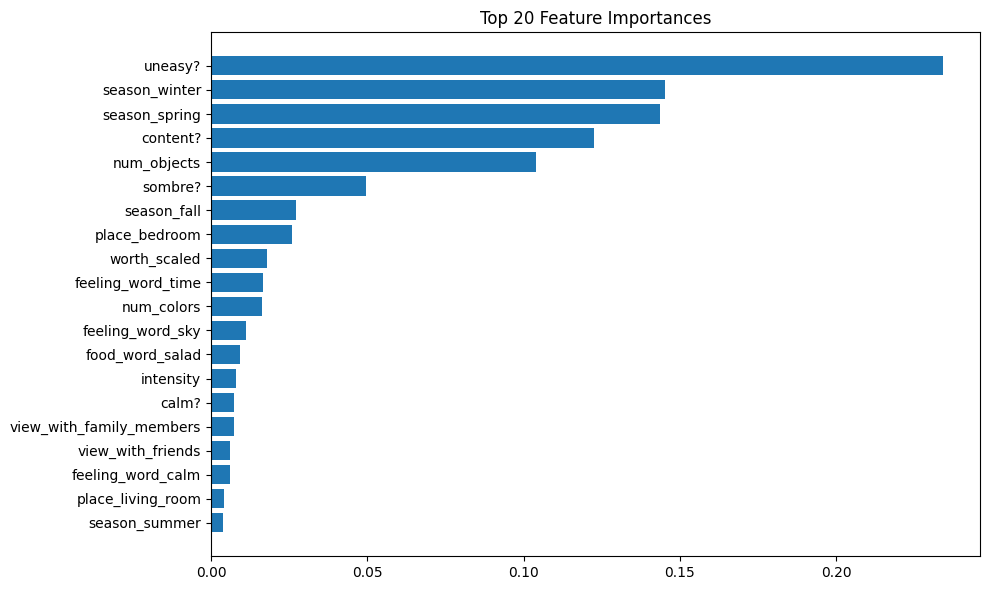

In [72]:
#feature importance plot

importances = clf.feature_importances_
feat_names = X_train_groups["F_all_features"].columns
indices = np.argsort(importances)[::-1][:20]  # top 20

plt.figure(figsize=(10, 6))
plt.barh([feat_names[i] for i in indices[::-1]], importances[indices[::-1]])
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()